In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import numpy as np
import pickle

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

In [2]:
def load_array_data(base_dirs: dict[str, Path]):
    """
    Load all EDM data as arrays.

    Returns:
        data: dict
            data[edm_state][run_id] = {
                "X": X,  # lambda_frac grid
                "Y": Y,  # theta grid (mrad)
                "Z": Z,  # probability density
            }
    """
    data = {}
    for edm_state, dir_path in base_dirs.items():
        state_data = {}
        if edm_state == "With" or edm_state == "Without":
            filename_type = "G2_*.pkl"
        else:
            filename_type = "G2NEW_*.pkl"
        for file in sorted(dir_path.glob(filename_type)):
            run_id = int(file.stem.split("_")[1])
            with open(file, "rb") as f:
                X, Y, Z = pickle.load(f)
            state_data[run_id] = {
                "X": X,
                "Y": Y * 1000,
                "Z": Z,
            }
        data[edm_state] = state_data
    return data


base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

In [3]:
def calculate_metrics_array(Z, Y, N, w=None):
    probs = N * Z * 1e-3

    if w is None:
        n = np.sum(probs)
        if n == 0:
            return np.nan, np.nan, np.nan
        mean = np.sum(probs * Y) / n
        var = np.sum(probs * (Y - mean) ** 2) / (n-1)
        sig = np.sqrt(max(var, 0.0))
        sem = sig / np.sqrt(n)
        return mean, sig, sem

    # Weighted version
    w = np.abs(w)
    n = np.sum(probs * w)
    if n == 0:
        return np.nan, np.nan, np.nan

    neff = (np.sum(probs * w) ** 2) / np.sum(probs * w ** 2)
    neff = max(neff, 1.0)

    mean = np.sum(w * probs * Y) / n
    var = np.sum(probs * w * (Y - mean) ** 2) / (n-1)
    sig = np.sqrt(max(var, 0.0))
    sem = sig / np.sqrt(neff)
    return mean, sig, sem

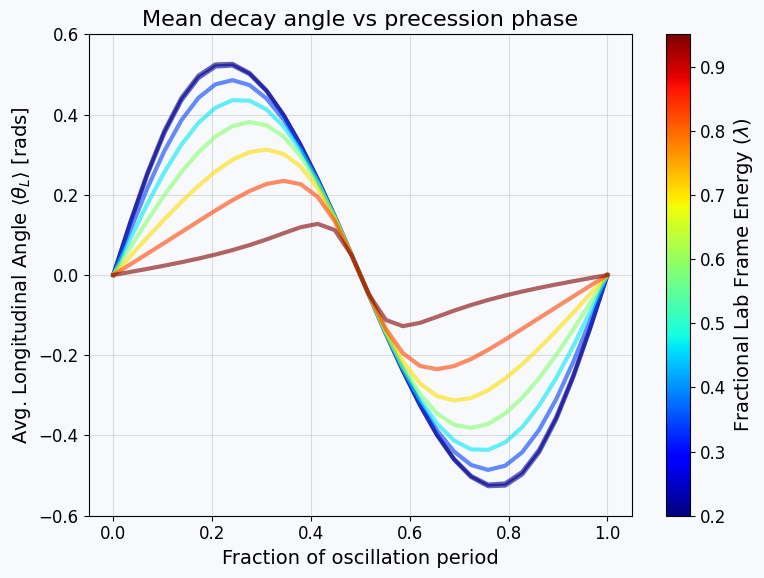

In [4]:
state = "With New" 

run_ids = np.arange(0,29,1)
Xg = data_all[state][run_ids[0]]["X"]   # (500,500)
Yg = data_all[state][run_ids[0]]["Y"]   # (500,500)

lam_axis = Xg[0, :]                     # (500,)
theta_axis_mrad = Yg[:, 0]              # (500,)

tfrac = np.linspace(0, 1, len(run_ids)+1) 

lam_targets = np.linspace(0.1, 0.95, 8)
lam_idx = [int(np.argmin(np.abs(lam_axis - l))) for l in lam_targets]
lam_used = lam_axis[lam_idx]

cmap = plt.get_cmap("jet")
norm = mpl.colors.Normalize(vmin=lam_used.min(), vmax=lam_used.max())

fig, ax = plt.subplots(figsize=(8, 6))

for j in lam_idx:
    means = []
    for run_id in run_ids:
        Z2d = data_all[state][run_id]["Z"]
        Z_1d = Z2d[:, j]
        mean, std, sem = calculate_metrics_array(Z_1d, theta_axis_mrad, 1e6)
        means.append(mean)
    means.append(means[0])
    ax.plot(tfrac, means, lw=3, color=cmap(norm(lam_axis[j])), alpha=0.6)

ax.set_title("Mean decay angle vs precession phase")
ax.set_xlabel("Fraction of oscillation period")
ax.set_ylabel(r"Avg. Longitudinal Angle $\langle \theta_L \rangle$ [rads]")
ax.grid(True, alpha=0.4)
ax.set_facecolor("#F7F9FC")
fig.set_facecolor("#F7F9FC")
ax.set_ylim([-0.6, 0.6])

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label=r"Fractional Lab Frame Energy $(\lambda)$")

fig.tight_layout()
plt.savefig(r"C:\Users\JakeS\Documents\Masters Project\Poster pdfs\precession w edm.png")
plt.show()

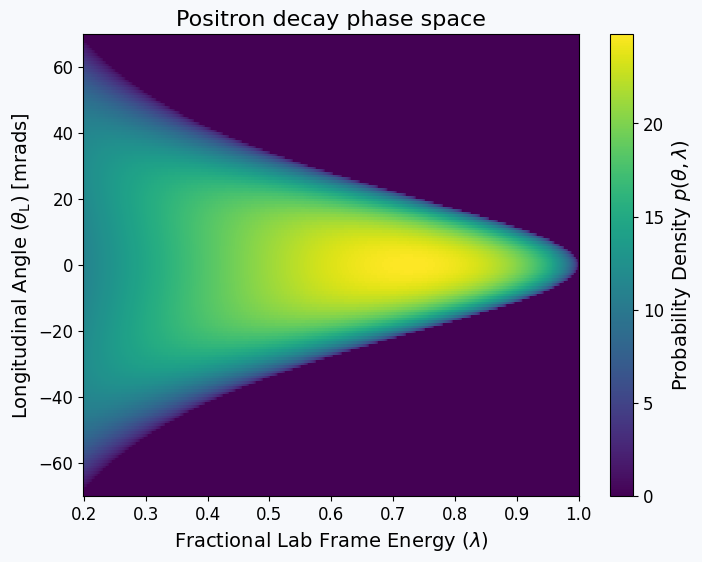

In [9]:
X = data_all["With"][0]["X"]
Y = data_all["With"][0]["Y"]
Z = data_all["With"][0]["Z"]

cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(vmin=Z.min(), vmax=Z.max())

fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")
ax.set_ylim([-70,70])
ax.set_xlabel(r"Fractional Lab Frame Energy ($\lambda$)")
ax.set_ylabel(r"Longitudinal Angle ($\theta_\mathrm{L}$) [mrads]")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

ax.set_facecolor("#F7F9FC")
fig.set_facecolor("#F7F9FC")

fig.colorbar(sm, ax=ax, label=r"Probability Density $p(\theta,\lambda)$")
ax.set_title("Positron decay phase space")
plt.savefig("C:/Users/JakeS/Documents/Masters Project/Poster pdfs/positron phase space.png")
plt.show()